In [1]:
# Downloading Dependencies
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd;
import numpy as np;

In [3]:
#reading training data
df = pd.read_csv("ChurnZero_dataset_v1.csv");
print(df) 

      customer_id  churn  age  gender marital_status education_level  \
0          133001      0   36  Female        Married         Unknown   
1          133002      1   44    Male         Single     High School   
2          133003      0   46    Male        Married     High School   
3          133004      0   36  Female        Married        Graduate   
4          133005      0   50    Male         Single        Graduate   
...           ...    ...  ...     ...            ...             ...   
8096       141097      0   46  Female        Married     High School   
8097       141098      0   52  Female        Married     High School   
8098       141099      1   61  Female         Single        Graduate   
8099       141100      0   43  Female        Married        Graduate   
8100       141101      0   52  Female         Single      Uneducated   

      dependent_count occupation_type  annual_income   income_band  ...  \
0                   0        Salaried          22256        

<---------------------------------------------------------------------------------------------------------------------------------------------------------->

Seperating Numerical And Categorical Features

In [4]:
# Select all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('churn')

# <---------------------------------------------------------------------------------------->

# Select all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

Outliers Detection And Operations

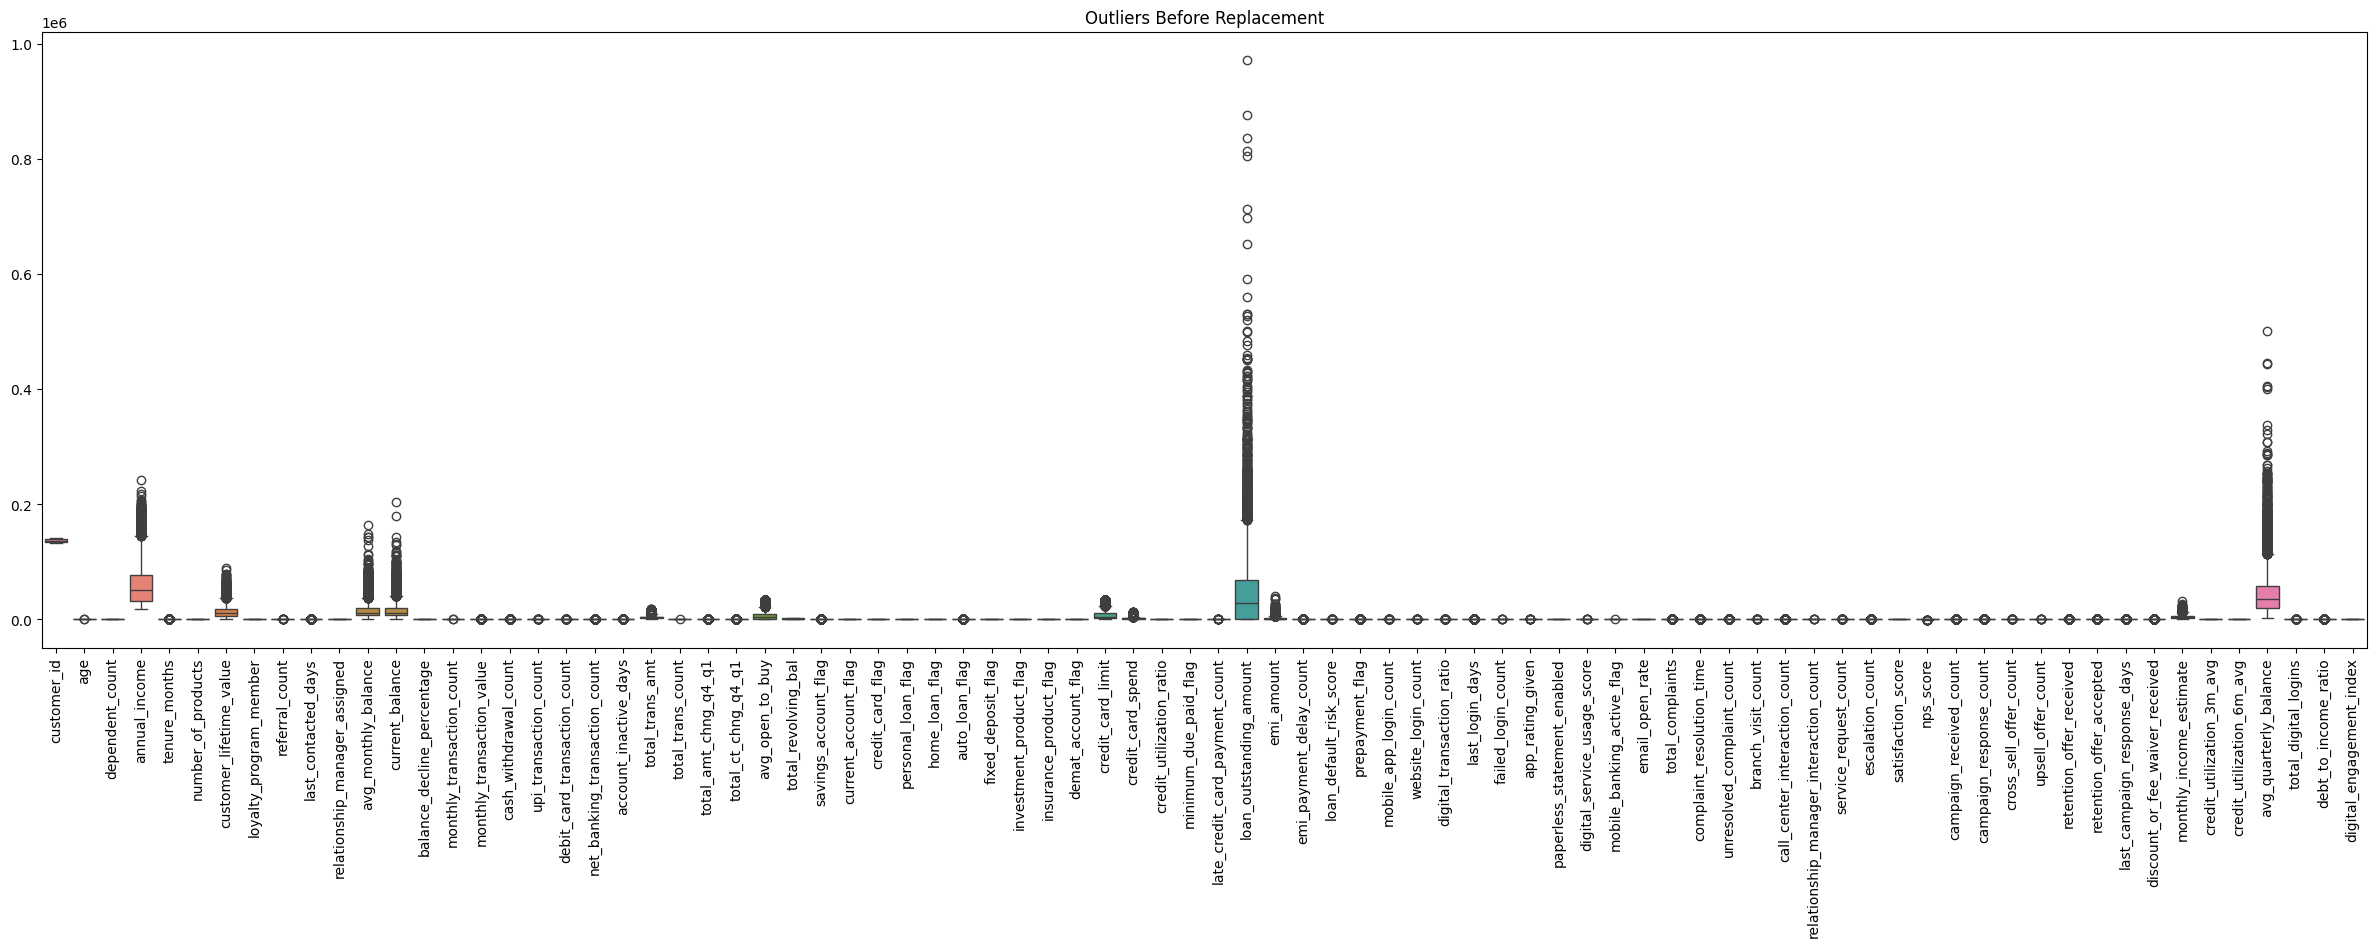

In [5]:
#Detecting Outliers
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30,8))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.title("Outliers Before Replacement")
plt.show()

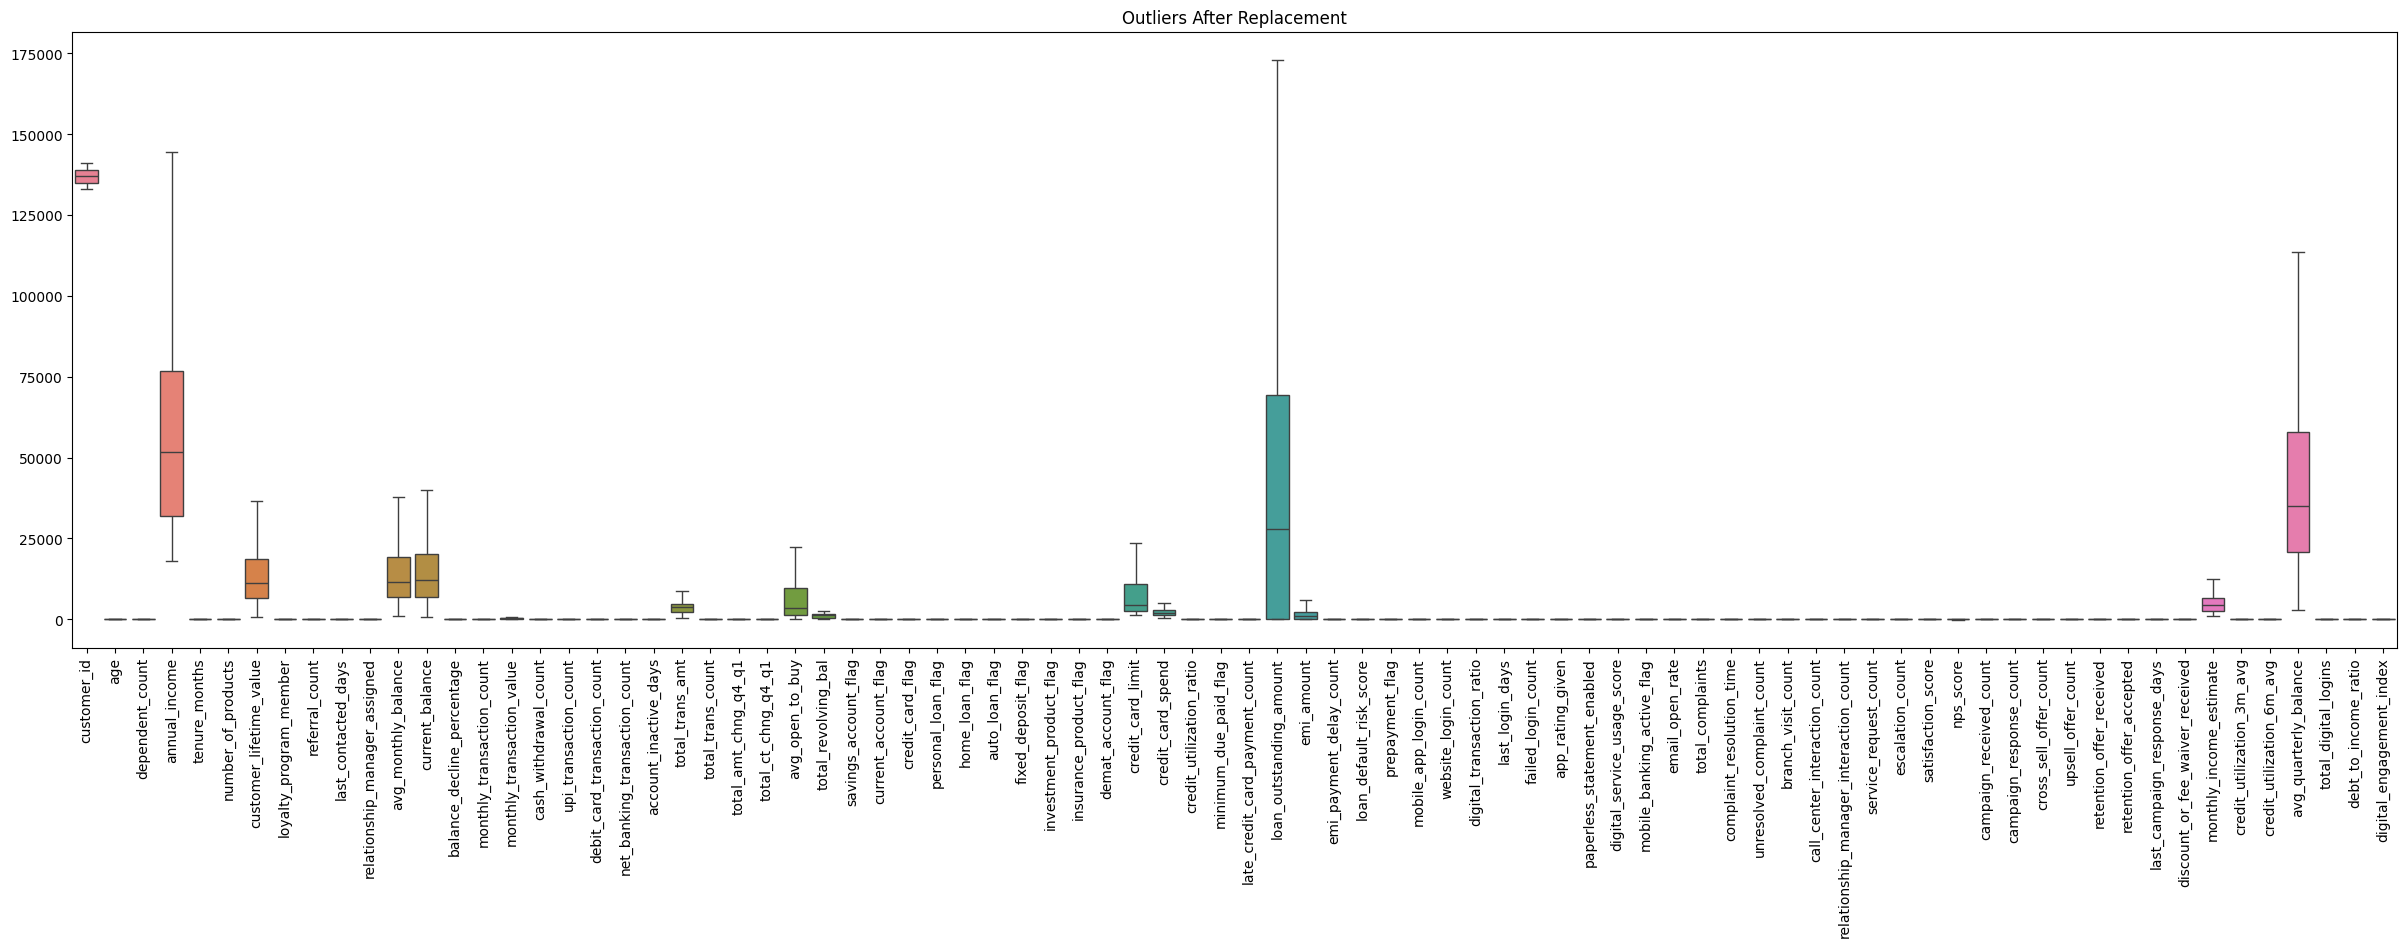

In [6]:
#Replacement of outliers with upper and lower values
for col in num_cols:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1   # Calculate IQR (Interquartile Range)

    # Define lower and upper bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper) # Replace outliers using clipping

# <---------------------------------------------------------------------------------------->

#Outliers graph after raplacement
plt.figure(figsize=(30,8))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.title("Outliers After Replacement")
plt.show()

Checking And Imputing Missing Values With Median

In [7]:
# Checking For Missing Values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values.sort_values(ascending=False))

#Median Imputation
for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

app_rating_given    4541
dtype: int64


<---------------------------------------------------------------------------------------------------------------------------------------------------------->

EDA (Exploratory Data Analysis)

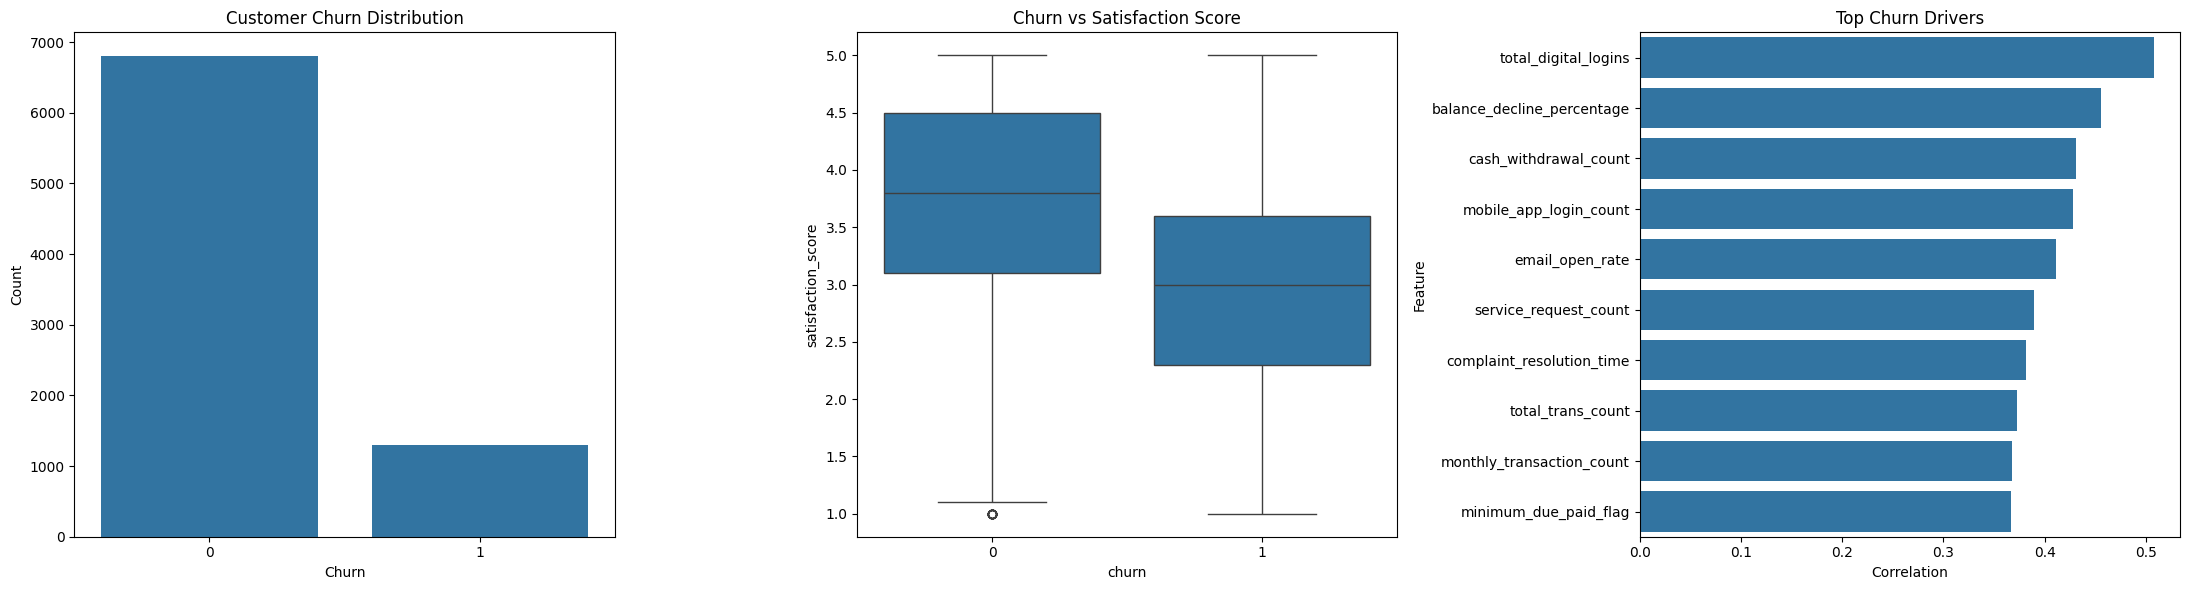

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot layout
fig, axes = plt.subplots(1, 3, figsize=(22,6))

# <---------------------------------------------------------------------------------------->

# 1. Churn Distribution
sns.countplot(
    x='churn',
    data=df,
    ax=axes[0]
)
axes[0].set_title("Customer Churn Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

# <---------------------------------------------------------------------------------------->

# 2. Churn vs Satisfaction Score
sns.boxplot(
    x='churn',
    y='satisfaction_score',
    data=df,
    ax=axes[1]
)
axes[1].set_title("Churn vs Satisfaction Score")

# <---------------------------------------------------------------------------------------->

# 3. Top Churn Drivers

corr_with_churn = df.corr(
    numeric_only=True
)['churn']

corr_with_churn = corr_with_churn.drop('churn')

top_features = corr_with_churn.abs().sort_values(
    ascending=False
).head(10)

importance = pd.DataFrame({
    'Feature': top_features.index,
    'Correlation': top_features.values
})

# Plot
sns.barplot(
    x='Correlation',
    y='Feature',
    data=importance,
    ax=axes[2]
)

axes[2].set_title("Top Churn Drivers")

# <---------------------------------------------------------------------------------------->

# Final Layout
plt.tight_layout()
plt.show()

Seperating xp and yp for train test split

In [9]:
#seperating xp and yp for train test split
xp = df.drop('churn', axis=1)
yp = df['churn'];

Splitting Data For Training And Testing

In [10]:
#train test split
from sklearn.model_selection import train_test_split;
x_train,x_test,y_train,y_test = train_test_split(xp ,yp,test_size=0.2 , random_state=42)

Performing FeatureScaling & FeatureEncoding Using ColumnTransformer

In [11]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder;
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        
        # Scaling Numerical Features
        ("Scaling",
         StandardScaler(),
         num_cols
        ),
        
        # Encoding Categorical Features
        ("Encoding",
         OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         cat_cols
        )
    ]
)


x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

Creating Base Models

In [12]:
# Base Classification Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

#XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

#LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

#CatBoost
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0,
    random_state=42
)

base_models = [
    ("RF", rf_model),
    ("XGB", xgb_model),
    ("LGBM", lgbm_model),
    ("CAT", cat_model)
]

Training Models Using StackingClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Stacking Model
model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

#Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(x_train, y_train)

#Making Predictions
y_pred = pipeline.predict(x_test)

Calculating Performance of Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred)

# Print
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

<---------------------------------------------------------------------------------------------------------------------------------------------------------->

Predicting For Test dataset

In [ ]:
#Reading Test Dataset
test_df = pd.read_csv("ChurnZero_test_v1.csv")

# Churn prediction (0/1)
churn_prediction = pipeline.predict(test_df)

# Churn probability (0-1)
churn_probability = pipeline.predict_proba(test_df)[:, 1]

Creating Submission File

In [ ]:
submission = pd.DataFrame({
    "customer_id": test_df["customer_id"],
    "churn_prediction": churn_prediction,
    "churn_probability": churn_probability
})

print("\nShape:", submission.shape)

# Save Csv File
submission.to_csv("ChurnZero_NEURALCOSMO_Predictions.csv", index=False)
print("\nsubmission.csv created successfully.")